In [3]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import numpy as np

def select_candidates(uids, fractions, n_models, alpha=0.05):
    """
    Description:
        Run BH-FDR-corrected one-sided binomial test against the median
        baseline, returning significant uids and the lowest passing fraction.

    Args:
        uids: List of identifiers, one per entry.
        fractions: List of observed proportions (e.g. NAC fractions).
        n_models: List of sample sizes (per entry).
        alpha: FDR level.

    Returns:
        Tuple (set of significant uids, lowest significant fraction or None).
    """

    baseline = np.median(fractions)
    pvals = [binomtest(int(f * n), n, p=baseline, alternative='greater').pvalue
             for f, n in zip(fractions, n_models)]
    rejected, _, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
    candidates = {uids[i] for i in range(len(uids)) if rejected[i]}
    sig_fracs = [fractions[i] for i in range(len(uids)) if rejected[i]]
    threshold = min(sig_fracs) if sig_fracs else None
    return candidates, threshold


In [1]:
import pandas as pd

# suffix = '2C'
# result_path = f'./results/carA_homologs_nac_candidates_{suffix}.csv'
i = 8
result_path = f'./results/carA_holo_adi_amp_homologs_nac_candidates_modeller_{i}.csv'

df = pd.read_csv(result_path)
df_conf = df[(df['n_confident_holo'] >= 30) & (df['n_confident_apo'] >= 30)]

df_conf

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs,n_confident_apo
0,A0A010YLP6,0.461538,3;4;8;11;13;16;17;18;22;25;26;27;29;31;33;35;3...,52,2.256202,1.053541,0.48,1;3;6;7;9;12;15;18;19;20;21;22;23;24;25;26;29;...,100
1,A0A024JSK2,0.740000,1;2;3;5;6;7;8;9;10;11;12;14;15;16;18;19;20;21;...,50,2.233409,1.014292,0.59,1;2;3;5;6;7;8;9;10;12;13;14;15;20;21;22;24;26;...,100
2,A0A024JWI0,0.388889,5;10;11;14;15;16;18;19;22;26;28;30;32;36,36,2.798437,1.104170,0.85,2;3;4;5;7;8;9;11;12;13;14;15;16;17;18;19;20;21...,100
3,A0A024JZE3,0.000000,NaN,35,2.848906,1.121463,0.00,NaN,100
4,A0A024JZE8,0.317073,4;5;10;11;17;21;22;24;28;30;33;35;41,41,2.599685,1.051545,0.26,2;8;18;20;22;27;30;31;32;34;35;37;47;51;52;53;...,100
...,...,...,...,...,...,...,...,...,...
864,W9B0J1,0.657895,1;2;3;4;8;11;13;14;15;17;18;19;20;21;22;23;25;...,38,2.759306,1.117572,0.22,2;13;19;29;34;35;37;42;43;48;59;62;63;65;71;74...,100
866,X8A9W7,0.090909,11;21;33;44;54,55,2.368604,1.315014,0.11,11;12;35;47;50;56;57;58;67;84;97,100
867,X8CEN6,0.312500,2;3;6;13;14;17;21;23;26;32;35;37;39;40;47,48,2.357069,1.091025,0.55,1;2;3;4;6;7;8;10;13;14;15;17;18;19;20;22;24;25...,100
868,X8DPU6,0.730769,3;5;6;7;8;9;10;11;12;13;14;15;17;18;19;20;21;2...,52,2.429318,1.225821,0.88,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100


In [4]:

entries = df_conf['entry'].tolist()

nac_fraction_holo = df_conf['nac_fraction_holo'].tolist()
nac_fraction_apo = df_conf['nac_fraction_apo'].tolist()

n_conf_models_holo = df_conf['n_confident_holo'].tolist()
n_conf_models_apo = df_conf['n_confident_apo'].tolist()

sig_holo, thr_holo = select_candidates(entries, nac_fraction_holo, n_conf_models_holo)
sig_apo,  thr_apo  = select_candidates(entries, nac_fraction_apo,  n_conf_models_apo)
both = sig_holo & sig_apo

print(f"Holo:  {len(sig_holo):>3d} / {len(entries)}  (threshold: {thr_holo:.1%})")
print(f"Apo:   {len(sig_apo):>3d} / {len(entries)}  (threshold: {thr_apo:.1%})")
print(f"Both:  {len(both):>3d}")

Holo:  219 / 831  (threshold: 47.8%)
Apo:   345 / 831  (threshold: 54.0%)
Both:  175


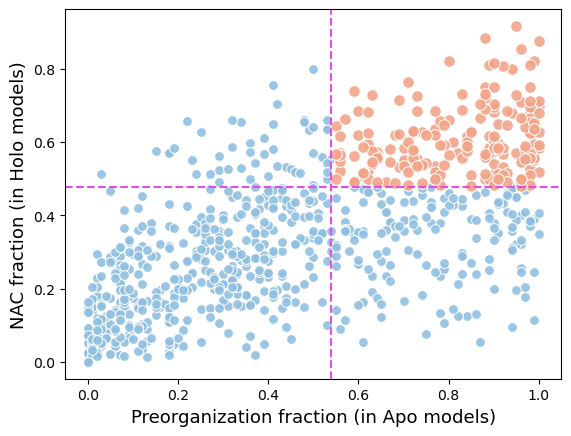

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays for boolean masking
apo = np.asarray(nac_fraction_apo)
holo = np.asarray(nac_fraction_holo)

# Mask for points above both thresholds (quadrant 1)
both_bool = (apo > thr_apo) & (holo > thr_holo)

# Base points (not in quadrant 1)
plt.scatter(apo[~both_bool], holo[~both_bool], s=50, c='#8fbfe0',
            edgecolors='white', linewidths=0.8, alpha=0.9)

# Highlighted points (above both thresholds)
plt.scatter(apo[both_bool], holo[both_bool], s=70, c='#f2a488',
            edgecolors='white', linewidths=0.8, alpha=0.9)

plt.xlabel('Preorganization fraction (in Apo models)', fontsize = 13)
plt.ylabel('NAC fraction (in Holo models)', fontsize = 13)

# Threshold lines with a softer color
plt.axhline(y=thr_holo, color="#e94be9", linestyle='--',
            label=f'Threshold: {thr_holo:.2%}')
plt.axvline(x=thr_apo, color='#e94be9', linestyle='--',
            label=f'Threshold: {thr_apo:.2%}')


plt.savefig(f'figs/nac_po_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

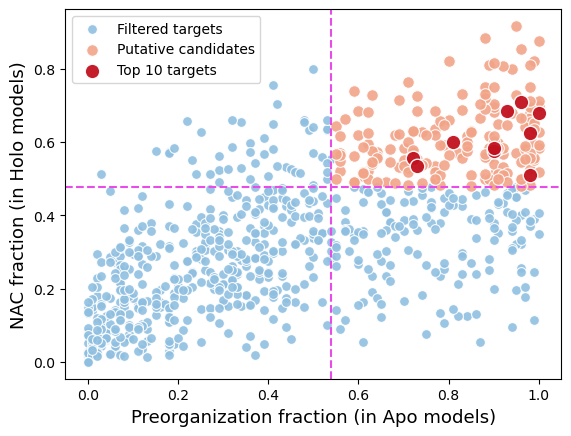

In [7]:
import numpy as np
import matplotlib.pyplot as plt


top10_ids = ['A0A542DCL6', 'H5U1W4', 'A0A9X7WHR6', 'A0A4V3I141', 'A0A100W5I0', 'A0A2N8P9Q2', 'D6Z860', 'A0ABY9WDG4', 'A0A498PZU2', 'A0A7U5MR51']
top10 = np.isin(np.asarray(entries), top10_ids)

# Convert to arrays for boolean masking
apo = np.asarray(nac_fraction_apo)
holo = np.asarray(nac_fraction_holo)

# Mask for points above both thresholds (quadrant 1)
both_bool = (apo > thr_apo) & (holo > thr_holo)

# plt.scatter(apo[~top10], holo[~top10], s=50, c='#8fbfe0',
#             edgecolors='white', linewidths=0.8, alpha=0.9)
plt.scatter(apo[~both_bool & ~top10], holo[~both_bool & ~top10], s=50, c='#8fbfe0',
            edgecolors='white', linewidths=0.8, alpha=0.9,
            label='Filtered targets')

# Highlighted points (above both thresholds, excluding top 10)
plt.scatter(apo[both_bool & ~top10], holo[both_bool & ~top10], s=70, c='#f2a488',
            edgecolors='white', linewidths=0.8, alpha=0.9,
            label='Putative candidates')

# Final top 10 targets, drawn last so they sit on top
plt.scatter(apo[top10], holo[top10], s=110, c='#c1121f',
            edgecolors='white', linewidths=1.0, alpha=0.95,
            label='Top 10 targets')

plt.xlabel('Preorganization fraction (in Apo models)', fontsize = 13)
plt.ylabel('NAC fraction (in Holo models)', fontsize = 13)

# Threshold lines with a softer color
plt.axhline(y=thr_holo, color="#e94be9", linestyle='--')
plt.axvline(x=thr_apo, color='#e94be9', linestyle='--')

plt.legend(fontsize=10, loc='upper left')
plt.savefig(f'figs/nac_po_distribution_top10.png', dpi=300, bbox_inches='tight')
plt.savefig(f'figs/nac_po_distribution_top10_adi_modeller.png', dpi=300, bbox_inches='tight')
plt.show()

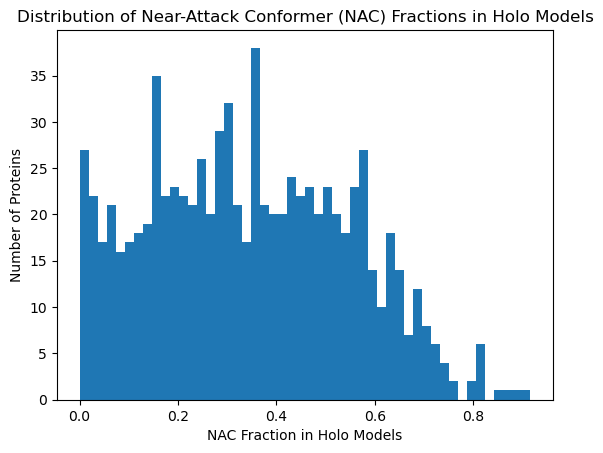

In [8]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_holo, bins=50)
plt.xlabel('NAC Fraction in Holo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

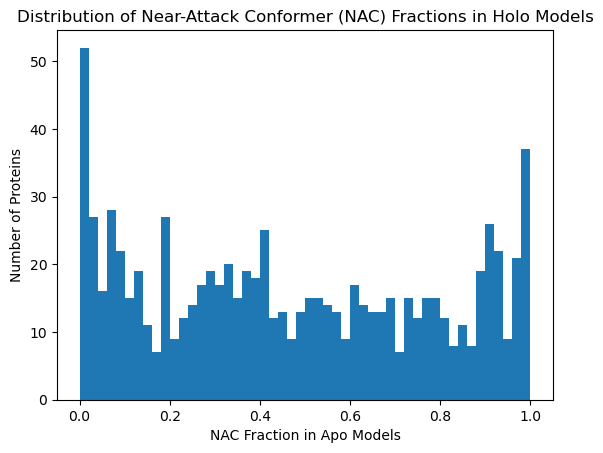

In [48]:
import matplotlib.pyplot as plt

plt.hist(nac_fraction_apo, bins=50)
plt.xlabel('NAC Fraction in Apo Models')
plt.ylabel('Number of Proteins')
plt.title('Distribution of Near-Attack Conformer (NAC) Fractions in Holo Models')
plt.show()

Split PLACER outputs into the models to satisfy NAC geometry
------------------------------------------------------------------------------

In [49]:
import os

cols = ['entry', 'nac_fraction_holo', 'nac_holo_idxs', 'n_confident_holo',
        'prmsd_mean', 'prmsd_std', 'nac_fraction_apo', 'nac_apo_idxs', 'n_confident_apo']

candidate_df = df_conf[df_conf['entry'].isin(both)].reset_index(drop=True)[cols]

candidate_df.to_csv(f'{os.path.splitext(result_path)[0]}_filtered.csv', index=False)
candidate_df

,entry,nac_fraction_holo,nac_holo_idxs,n_confident_holo,prmsd_mean,prmsd_std,nac_fraction_apo,nac_apo_idxs,n_confident_apo
0,A0A024JSK2,0.740000,1;2;3;5;6;7;8;9;10;11;12;14;15;16;18;19;20;21;...,50,2.233409,1.014292,0.59,1;2;3;5;6;7;8;9;10;12;13;14;15;20;21;22;24;26;...,100
1,A0A051UFG9,0.553191,2;4;5;6;7;11;12;13;16;17;18;19;21;22;23;24;27;...,47,2.557198,1.202763,0.73,2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;19;...,100
2,A0A0E4CLA0,0.820000,1;3;5;7;8;9;10;11;12;13;14;15;16;17;18;19;20;2...,50,2.437891,1.086323,0.99,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100
3,A0A0F5MSZ2,0.557692,1;3;5;7;10;11;13;14;15;16;17;18;19;22;23;24;25...,52,2.406730,1.147995,0.89,1;3;4;5;6;7;8;9;10;11;12;13;14;16;17;18;19;20;...,100
4,A0A0H5BB76,0.511628,3;8;10;11;12;13;15;17;18;19;23;25;26;27;29;31;...,43,2.441937,1.299760,0.90,2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;20;...,100
...,...,...,...,...,...,...,...,...,...
170,Q741P9,0.566667,2;3;4;6;7;8;10;11;12;13;14;16;19;20;24;28;29;3...,60,2.158302,1.325387,0.88,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100
171,V5XIA1,0.536585,2;3;4;6;7;8;9;12;13;14;15;16;22;23;24;25;26;27...,41,2.508172,1.261947,0.79,1;6;7;10;11;12;14;16;17;18;19;20;21;22;23;24;2...,100
172,W5WC87,0.816667,1;2;3;4;5;7;8;9;10;11;12;13;14;18;19;20;21;22;...,60,2.023050,1.177222,0.90,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100
173,X8DPU6,0.730769,3;5;6;7;8;9;10;11;12;13;14;15;17;18;19;20;21;2...,52,2.429318,1.225821,0.88,1;2;3;4;5;6;7;8;9;10;11;12;13;14;15;16;17;18;1...,100


In [50]:
import os
from Bio.PDB import PDBIO
from tqdm import tqdm

from process import structure

filename = f"carA_holo_adi_amp_homologs_modeller_100_{i}"
src_dir = f"outputs/placer/{filename}"
dst_dir = f"inputs/docking/{filename}"
os.makedirs(dst_dir, exist_ok=True)

io = PDBIO()
for _, row in tqdm(candidate_df.iterrows(), total=len(candidate_df)):
    base_name = row['entry']
    src_path = os.path.join(src_dir, f"{base_name}.relax_model.pdb")

    out_dir = os.path.join(dst_dir, base_name)
    os.makedirs(out_dir, exist_ok=True)

    models = structure.load_models_from_pdb(src_path)
    for idx in row['nac_holo_idxs'].split(';'):
        idx = int(idx)
        io.set_structure(models[int(idx) - 1])   # 1-based -> 0-based
        io.save(os.path.join(out_dir, f"{base_name}.relax_model_{idx}.pdb"))

100%|██████████| 175/175 [02:40<00:00,  1.09it/s]


Create .sh file to run Docking simulation
------------------------------------------

In [51]:
import os
    
input_dir = os.path.abspath(f"inputs/docking/{filename}")
output_dir = os.path.abspath(f"outputs/docking/{filename}")
ligand_pdbqt = os.path.abspath("inputs/rosetta/subs/adi.pdbqt")
box_path = os.path.join(input_dir, "box_coords.box.txt")
sh_path = os.path.join(input_dir, "run_vina.sh")

# Collect entries (directories) up front so we know the total for progress logging
entries = [
    e for e in sorted(os.listdir(input_dir))
    if os.path.isdir(os.path.join(input_dir, e))
]
total = len(entries)

with open(sh_path, 'w') as f:
    f.write("#!/bin/bash\n")
    f.write("set -e\n\n")

    # --- progress logging setup ---
    f.write(f"TOTAL={total}\n")
    f.write("START=$SECONDS\n")
    f.write("i=0\n")

    f.write("fmt(){ printf '%02d:%02d:%02d' $(($1/3600)) $(($1%3600/60)) $(($1%60)); }\n\n")

    for entry in entries:
        entry_dir = os.path.join(input_dir, entry)
        out_dir = os.path.join(output_dir, entry)

        # progress line for this entry
        f.write("i=$((i+1))\n")
        f.write(f'echo "[$i/$TOTAL] docking {entry} (elapsed $(fmt $((SECONDS-START))))"\n')

        f.write(f"mkdir -p {out_dir}\n")
        f.write(f"cd {entry_dir}\n")

        for pdb_name in sorted(os.listdir(entry_dir)):
            if not pdb_name.endswith('.pdb'):
                continue
            base = pdb_name.replace('.pdb', '')

            # Remove ADI HETATM lines in-place (keep AMP)
            f.write(f"grep -v 'ADI' {pdb_name} > {pdb_name}.tmp && mv {pdb_name}.tmp {pdb_name}\n")
            # Convert pdb to pdbqt (suppress obabel warnings on stderr)
            f.write(f"obabel {pdb_name} -O {base}.pdbqt -xr -xh 2>/dev/null\n")
            # Dock (vina 1.2.x has no --log; redirect stdout to log file)
            f.write(
                f"vina --receptor {base}.pdbqt --ligand {ligand_pdbqt} "
                f"--config {box_path} --cpu 8 "
                f"--out {out_dir}/ligand_{base}.pdbqt > {out_dir}/{base}.log 2>&1\n"
            )

        # done with this entry: report elapsed + ETA for the rest
        f.write("elapsed=$((SECONDS-START))\n")
        f.write("remaining=$(( i>0 ? (TOTAL-i)*elapsed/i : 0 ))\n")
        f.write('echo "    done $i/$TOTAL | elapsed $(fmt $elapsed) | ETA $(fmt $remaining)"\n\n')

    f.write('echo "all done in $(fmt $((SECONDS-START)))"\n')

In [ ]:
set_color pastel_pink, [0.96, 0.76, 0.80]
set_color pastel_blue, [0.68, 0.80, 0.94]
set_color pastel_green, [0.72, 0.90, 0.75]
set_color pastel_yellow, [0.97, 0.91, 0.68]

# Apply colors to each chain of the protein object
# Replace '4YSY_bx_SDH_receptor_ligand_flp_swiss' with your object name, and chain IDs (A-D) if different
color pastel_pink, 4YSY_bx_SDH_receptor_ligand_flp_swiss and chain A
color pastel_blue, 4YSY_bx_SDH_receptor_ligand_flp_swiss and chain B
color pastel_green, 4YSY_bx_SDH_receptor_ligand_flp_swiss and chain C
color pastel_yellow, 4YSY_bx_SDH_receptor_ligand_flp_swiss and chain D